In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=5,
    noise=15,
    random_state=42
)

columns = ["Feature1","Feature2","Feature3","Feature4","Feature5"]

df = pd.DataFrame(X, columns=columns)
df["HousePrice"] = y

df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,HousePrice
0,-0.385314,0.199060,-0.600217,0.462103,0.069802,-19.876024
1,0.130741,1.632411,-1.430141,-1.247783,-0.440044,-121.994064
2,-0.773010,0.224092,0.012592,-0.401220,0.097676,19.221414
3,-0.576771,-0.050238,-0.238948,0.270457,-0.907564,-61.045683
4,-0.575818,0.614167,0.757508,-0.220970,-0.530501,27.922024


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
linear = LinearRegression()

linear.fit(X_train, y_train)

print("Intercept:", linear.intercept_)

print("\nCoefficients")

for feature, coef in zip(X.columns, linear.coef_):
    print(feature, ":", round(coef,2))

Intercept: 1.459853500610457

Coefficients
Feature1 : 2.67
Feature2 : 11.29
Feature3 : 65.51
Feature4 : 18.54
Feature5 : 69.48


In [5]:
pred = linear.predict(X_test)

In [6]:
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2 Score:", r2)

MSE : 191.38131501357884
RMSE: 13.83406357559408
MAE : 11.607382833958672
R2 Score: 0.9779730313771264


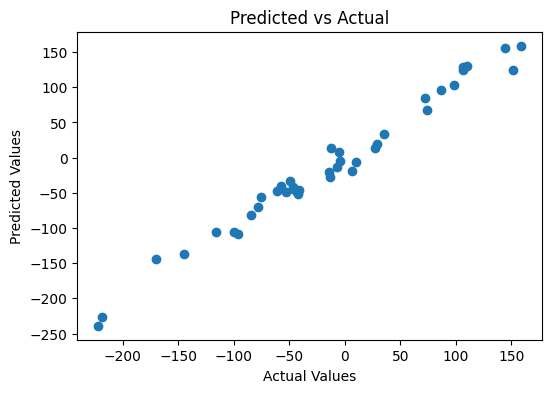

In [7]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")

plt.show()

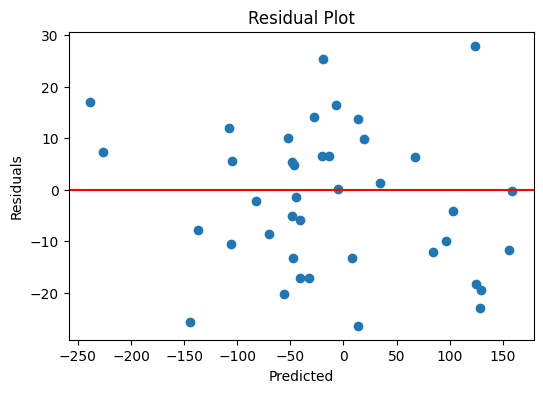

In [8]:
residuals = y_test - pred

plt.figure(figsize=(6,4))

plt.scatter(pred, residuals)

plt.axhline(0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [9]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [10]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [11]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "R2 Score":[
        r2_score(y_test,pred),
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ],

    "MAE":[
        mean_absolute_error(y_test,pred),
        mean_absolute_error(y_test,ridge_pred),
        mean_absolute_error(y_test,lasso_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred)),
        np.sqrt(mean_squared_error(y_test,ridge_pred)),
        np.sqrt(mean_squared_error(y_test,lasso_pred))
    ]

})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.977973,11.607383,13.834064
1,Ridge,0.978211,11.500560,13.759185
2,Lasso,0.978044,11.576336,13.811705


In [12]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "R2 Score":[
        r2_score(y_test,pred),
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ],

    "MAE":[
        mean_absolute_error(y_test,pred),
        mean_absolute_error(y_test,ridge_pred),
        mean_absolute_error(y_test,lasso_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred)),
        np.sqrt(mean_squared_error(y_test,ridge_pred)),
        np.sqrt(mean_squared_error(y_test,lasso_pred))
    ]

})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.977973,11.607383,13.834064
1,Ridge,0.978211,11.500560,13.759185
2,Lasso,0.978044,11.576336,13.811705


In [13]:
results.to_csv("LinearRegression_Model_Comparison.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
